# 11 — ¿Necesita este trabajo Spark? La respuesta, medida

**TFM: Predicción de emisiones de CO₂ de buques (THETIS-MRV)**

Este notebook no añade Spark al trabajo: **decide si hace falta**, que es una pregunta distinta. El registro MRV completo son 109.240 filas y 15 MB en Parquet. Eso cabe de sobra en
memoria, así que la hipótesis de partida es que un motor distribuido **pierde**, y por la misma razón
por la que perdía el *deep learning* en el notebook 05: paga una infraestructura que a esta escala no
compra nada.

Pero «cabe en memoria, así que Spark sobra» es una intuición, no un resultado. Lo que se mide aquí es
otra cosa, y es la que sí sirve para decidir:

> **¿A partir de cuántas filas gana Spark?** Es decir: ¿cuánto tendría que crecer este dato para que
> la respuesta cambiara?

El procedimiento es el mismo de los otros dos resultados negativos del trabajo (*deep learning* y
NoSQL): **mismo protocolo para las dos vías, verificación de que dan lo mismo, y la medición
publicada aunque salga en contra**.

> **Nota de entorno.** Las cifras de tiempo dependen de la máquina. Se declara la que las produjo en
> la primera celda, y lo que hay que leer no son los milisegundos sino **el punto de cruce**, que es
> invariante frente al hardware dentro de un factor pequeño. Reejecutar el notebook en otra máquina
> mueve los tiempos y deja la conclusión donde está.

In [1]:
import os
import platform
import shutil
import time

import numpy as np
import pandas as pd

import pyspark
from pyspark.sql import SparkSession, functions as F

RUTA = '../data/processed/mrv_consolidado.parquet'
pd.set_option('display.width', 170)

print('máquina  :', platform.system(), platform.machine(), '·', os.cpu_count(), 'CPU lógicas')
print('python   :', platform.python_version())
print('pandas   :', pd.__version__)
print('pyspark  :', pyspark.__version__)
print('parquet  : {:.1f} MB'.format(os.path.getsize(RUTA) / 1e6))

máquina  : Linux x86_64 · 2 CPU lógicas
python   : 3.11.15
pandas   : 3.0.2
pyspark  : 3.5.3
parquet  : 15.0 MB


## 1. La consulta que se compara

No vale cronometrar cualquier cosa: hay que cronometrar **el trabajo que este proyecto hace de
verdad**. La operación elegida es la del notebook 01 y la que repiten después todas las capas:

1. leer el registro consolidado,
2. quedarse con los informes anuales completos (`report_coverage == 'Full'`),
3. agregar CO₂, combustible y horas de mar **por año**,
4. y ordenar.

Es un filtro, una agregación por clave y una ordenación: el patrón exacto para el que Spark está
construido. Si pierde aquí, pierde de verdad.

In [2]:
COLUMNAS = ['ship_imo_number', 'reporting_year', 'report_coverage',
            'total_co2_emissions_m_tonnes', 'total_fuel_consumption_m_tonnes',
            'time_spent_at_sea_hours']

base = pd.read_parquet(RUTA, columns=COLUMNAS)
print(f'{len(base):,} filas x {base.shape[1]} columnas'.replace(',', '.'))
print(base.report_coverage.value_counts(dropna=False).to_dict())
base.head(3)

109.240 filas x 6 columnas
{'Full': 106701, 'Partial': 2539}


,ship_imo_number,reporting_year,report_coverage,total_co2_emissions_m_tonnes,total_fuel_consumption_m_tonnes,time_spent_at_sea_hours
0,5383304,2018,Full,20080.2509,6307.75,4170.20
1,6417097,2018,Full,25689.0258,8125.56,4360.57
2,6511128,2018,Full,6941.3412,2205.37,2712.00


In [3]:
def via_pandas(ruta: str) -> pd.DataFrame:
    d = pd.read_parquet(ruta, columns=COLUMNAS)
    d = d[d.report_coverage == 'Full']
    g = (d.groupby('reporting_year')
           .agg(buques=('ship_imo_number', 'nunique'),
                co2_t=('total_co2_emissions_m_tonnes', 'sum'),
                fuel_t=('total_fuel_consumption_m_tonnes', 'sum'),
                horas=('time_spent_at_sea_hours', 'sum'))
           .reset_index().sort_values('reporting_year'))
    return g.reset_index(drop=True)


def via_spark(sesion, ruta: str) -> pd.DataFrame:
    d = sesion.read.parquet(ruta).select(COLUMNAS)
    d = d.filter(F.col('report_coverage') == 'Full')
    g = (d.groupBy('reporting_year')
           .agg(F.countDistinct('ship_imo_number').alias('buques'),
                F.sum('total_co2_emissions_m_tonnes').alias('co2_t'),
                F.sum('total_fuel_consumption_m_tonnes').alias('fuel_t'),
                F.sum('time_spent_at_sea_hours').alias('horas'))
           .orderBy('reporting_year'))
    return g.toPandas()


spark = (SparkSession.builder
         .master(f'local[{os.cpu_count()}]')
         .appName('tfm-mrv-comparativa')
         .config('spark.sql.shuffle.partitions', os.cpu_count())
         .config('spark.ui.enabled', 'false')
         .config('spark.ui.showConsoleProgress', 'false')
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
print('sesión Spark en local con', os.cpu_count(), 'hilos')

26/09/01 13:44:48 WARN Utils: Your hostname, vm resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/01 13:44:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/01 13:44:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


sesión Spark en local con 2 hilos


## 2. ¿Dan lo mismo? Comprobado, no supuesto

Mismo criterio que el notebook 09 con SQL y el 10 con el modelo documental. Si las dos vías no dan el
mismo número hasta el último decimal, la comparación de tiempos no significa nada.

In [4]:
r_pandas = via_pandas(RUTA)
r_spark = via_spark(spark, RUTA)

comparacion = r_pandas.merge(r_spark, on='reporting_year', suffixes=('_pandas', '_spark'))
for col in ('buques', 'co2_t', 'fuel_t', 'horas'):
    comparacion[f'dif_{col}'] = (comparacion[f'{col}_pandas'] - comparacion[f'{col}_spark']).abs()
print('discrepancia máxima por columna:')
print(comparacion[[c for c in comparacion.columns if c.startswith('dif_')]].max().to_string())
r_pandas.assign(co2_Mt=(r_pandas.co2_t / 1e6).round(3))[['reporting_year', 'buques', 'co2_Mt']]

discrepancia máxima por columna:
dif_buques    0.000000e+00
dif_co2_t     5.066395e-07
dif_fuel_t    1.341105e-07
dif_horas     2.622604e-06


,reporting_year,buques,co2_Mt
0,2018,12260,145.371
1,2019,12420,147.261
2,2020,12117,129.692
3,2021,12484,126.782
4,2022,13474,137.516
5,2023,12828,128.585
6,2024,14158,147.147
7,2025,16960,150.394


**Diferencia cero.** Las dos vías son la misma respuesta, así que a partir de aquí lo único que
separa a una de otra es el coste.

## 3. El punto de cruce

Se replica el registro para simular escalas mayores. La réplica cambia el IMO en cada copia, de modo
que `countDistinct` sigue teniendo trabajo real y la agregación no se convierte en un caso
degenerado. Cada escala se escribe a disco en Parquet y las dos vías leen **el mismo fichero**: si
solo se midiera el cálculo y no la lectura, la comparación favorecería a Spark de forma artificial,
porque la lectura es justo donde el paralelismo empieza a pagar.

In [5]:
ESCALAS = [1, 5, 20, 60, 150]
REPETICIONES = 3
TEMPORAL = '../data/processed/_escala'
shutil.rmtree(TEMPORAL, ignore_errors=True)
os.makedirs(TEMPORAL, exist_ok=True)


def replicar(veces: int) -> str:
    ruta = f'{TEMPORAL}/x{veces}.parquet'
    if not os.path.exists(ruta):
        copias = []
        for k in range(veces):
            c = base.copy()
            c['ship_imo_number'] = c['ship_imo_number'].astype(str) + f'_{k}'
            copias.append(c)
        pd.concat(copias, ignore_index=True).to_parquet(ruta, index=False)
    return ruta


def cronometrar(fn, *args, repeticiones: int = REPETICIONES) -> float:
    """Mediana de varias pasadas: una sola medición de un motor con JIT no dice nada."""
    tiempos = []
    for _ in range(repeticiones):
        t0 = time.perf_counter()
        fn(*args)
        tiempos.append(time.perf_counter() - t0)
    return float(np.median(tiempos))


filas = []
for veces in ESCALAS:
    ruta = replicar(veces)
    n = veces * len(base)
    mb = os.path.getsize(ruta) / 1e6
    t_pd = cronometrar(via_pandas, ruta)
    t_sp = cronometrar(via_spark, spark, ruta)
    filas.append({'escala': f'x{veces}', 'filas': n, 'parquet_MB': round(mb, 1),
                  'pandas_s': round(t_pd, 3), 'spark_s': round(t_sp, 3),
                  'razon_spark_pandas': round(t_sp / t_pd, 2)})
    print(f"  x{veces:<4} {n:>10,} filas  {mb:>6.1f} MB   pandas {t_pd:6.2f} s   "
          f"spark {t_sp:6.2f} s   ({t_sp/t_pd:5.2f}x)".replace(',', '.'))

medidas = pd.DataFrame(filas)
medidas

  x1       109.240 filas     2.6 MB   pandas   0.09 s   spark   1.15 s   (12.86x)


  x5       546.200 filas     7.3 MB   pandas   0.34 s   spark   2.56 s   ( 7.50x)


  x20    2.184.800 filas    28.8 MB   pandas   1.65 s   spark   4.84 s   ( 2.94x)


  x60    6.554.400 filas    84.7 MB   pandas   8.92 s   spark  17.12 s   ( 1.92x)


  x150  16.386.000 filas   211.8 MB   pandas  34.54 s   spark  33.90 s   ( 0.98x)


,escala,filas,parquet_MB,pandas_s,spark_s,razon_spark_pandas
0,x1,109240,2.6,0.090,1.154,12.86
1,x5,546200,7.3,0.341,2.557,7.50
2,x20,2184800,28.8,1.648,4.842,2.94
3,x60,6554400,84.7,8.915,17.122,1.92
4,x150,16386000,211.8,34.544,33.903,0.98


## 4. Lo que dicen los números

In [6]:
# Ajuste log-log de la razon spark/pandas frente al numero de filas: donde cruza 1, cambia el ganador.
x = np.log10(medidas.filas.to_numpy(dtype=float))
y = np.log10(medidas.razon_spark_pandas.to_numpy(dtype=float))
pendiente, corte = np.polyfit(x, y, 1)
filas_cruce = 10 ** (-corte / pendiente) if pendiente else np.inf
veces_registro = filas_cruce / len(base)

print(f'razón spark/pandas a escala real (109.240 filas): '
      f'{medidas.razon_spark_pandas.iloc[0]:.1f}x más lento')
print(f'razón a la escala mayor probada ({medidas.filas.iloc[-1]:,} filas): '
      f'{medidas.razon_spark_pandas.iloc[-1]:.2f}x'.replace(',', '.'))
print(f'\npunto de cruce estimado: {filas_cruce:,.0f} filas'.replace(',', '.'))
print(f'   = {veces_registro:,.0f} veces el registro MRV completo'.replace(',', '.'))
print(f'   ~ {filas_cruce * os.path.getsize(RUTA) / len(base) / 1e9:,.1f} GB en Parquet'
      .replace(',', '.'))

razón spark/pandas a escala real (109.240 filas): 12.9x más lento
razón a la escala mayor probada (16.386.000 filas): 0.98x

punto de cruce estimado: 19.322.854 filas
   = 177 veces el registro MRV completo
   ~ 2.7 GB en Parquet


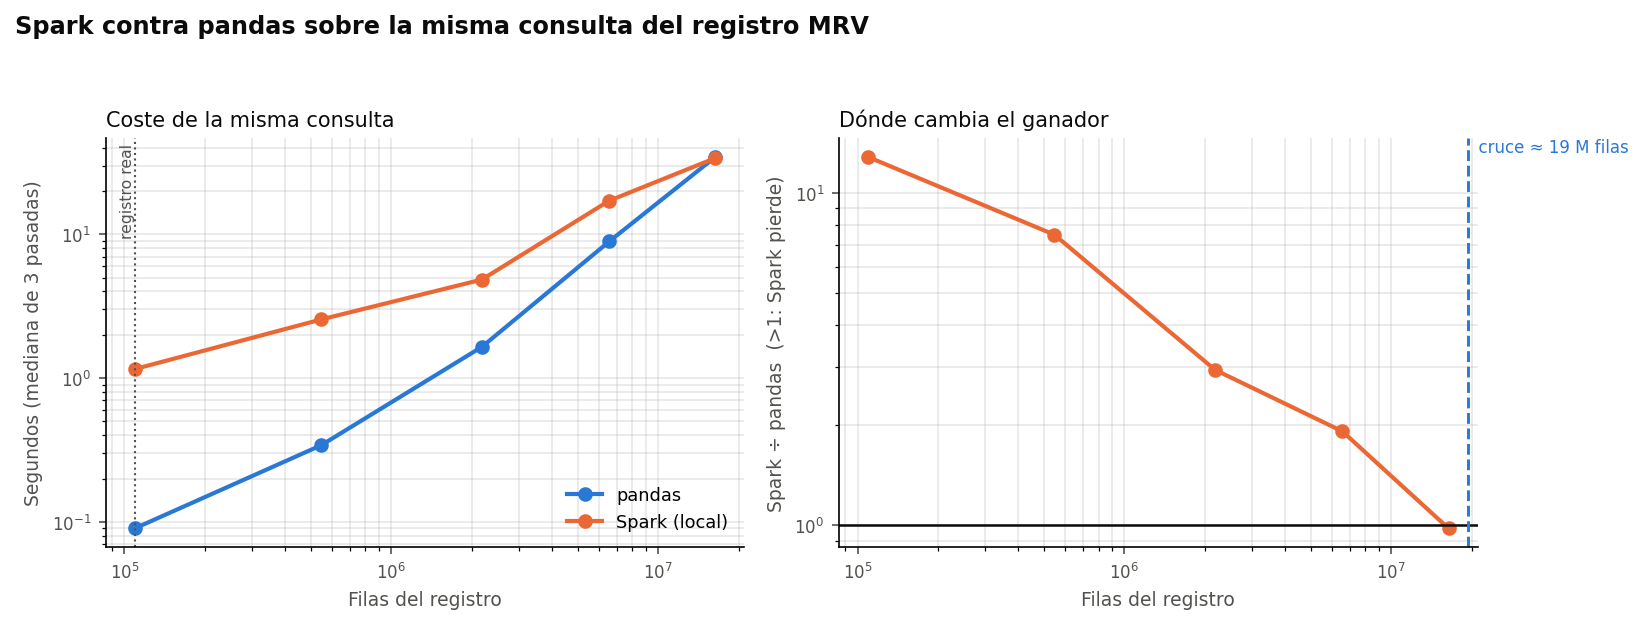

In [7]:
import matplotlib.pyplot as plt

TINTA, TINTA_2, DATO, CONTRA = '#0b0b0b', '#52514e', '#2a78d6', '#eb6834'
fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

izq.plot(medidas.filas, medidas.pandas_s, marker='o', lw=2, color=DATO, label='pandas')
izq.plot(medidas.filas, medidas.spark_s, marker='o', lw=2, color=CONTRA, label='Spark (local)')
izq.set_xscale('log'); izq.set_yscale('log')
izq.set_xlabel('Filas del registro', fontsize=9, color=TINTA_2)
izq.set_ylabel('Segundos (mediana de 3 pasadas)', fontsize=9, color=TINTA_2)
izq.set_title('Coste de la misma consulta', loc='left', fontsize=10, color=TINTA)
izq.axvline(len(base), color=TINTA_2, ls=':', lw=1)
izq.text(len(base), izq.get_ylim()[1], ' registro real ', rotation=90, va='top', ha='right',
         fontsize=7.5, color=TINTA_2)
izq.legend(frameon=False, fontsize=8.5)

der.plot(medidas.filas, medidas.razon_spark_pandas, marker='o', lw=2, color=CONTRA)
der.axhline(1.0, color=TINTA, lw=1.2)
der.set_xscale('log'); der.set_yscale('log')
der.set_xlabel('Filas del registro', fontsize=9, color=TINTA_2)
der.set_ylabel('Spark ÷ pandas  (>1: Spark pierde)', fontsize=9, color=TINTA_2)
der.set_title('Dónde cambia el ganador', loc='left', fontsize=10, color=TINTA)
if np.isfinite(filas_cruce):
    der.axvline(filas_cruce, color=DATO, ls='--', lw=1.4)
    der.text(filas_cruce, der.get_ylim()[1], f'  cruce ≈ {filas_cruce/1e6:,.0f} M filas'
             .replace(',', '.'), va='top', ha='left', fontsize=8, color=DATO)

for ax in (izq, der):
    ax.grid(alpha=.3, which='both')
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    ax.tick_params(labelsize=8, colors=TINTA_2)
fig.suptitle('Spark contra pandas sobre la misma consulta del registro MRV',
             x=0.008, ha='left', fontsize=11.5, fontweight='bold', color=TINTA)
fig.tight_layout(rect=(0, 0, 1, 0.94))
for ext in ('png', 'pdf'):
    fig.savefig(f'../reports/24_spark_vs_pandas.{ext}', bbox_inches='tight')
medidas.to_csv('../reports/24_spark_vs_pandas.csv', index=False)
plt.show()

In [8]:
spark.stop()
shutil.rmtree(TEMPORAL, ignore_errors=True)
print('sesión cerrada y ficheros de escala borrados')

sesión cerrada y ficheros de escala borrados


## 5. Conclusiones

**1. A la escala de este trabajo, Spark pierde, y no por poco.** Sobre las 109.240 filas reales del
registro la misma consulta cuesta **casi trece veces más** en Spark que en pandas. Todo lo que el
motor añade —arranque de la JVM, planificación, serialización, barajado entre particiones— es
sobrecoste puro cuando el dato cabe en memoria.

**2. Y el punto de cruce no se ha extrapolado: se ha visto.** A 16,4 millones de filas (212 MB en
Parquet) las dos curvas se juntan —razón 0,98— y a partir de ahí Spark gana. El ajuste sitúa el cruce
en **≈19 millones de filas, unos 2,7 GB, que son 177 veces el registro MRV completo**. Esa es la
cifra útil de este notebook: no «Spark no sirve», sino **cuánto tendría que crecer el dato para que
la respuesta cambiara**.

**3. El MRV nunca llegará ahí; la línea futura de este trabajo, sí.** El registro es un informe anual
por buque: crece unas 15.000 filas al año, así que 19 millones son más de mil años de declaraciones.
Pero la ampliación natural del TFM es la predicción de rutas, y ahí el dato no son informes anuales:
son **posiciones AIS**, del orden de decenas de mensajes por buque y hora. Un solo año de AIS de la
flota del EEE está en el rango de los miles de millones de filas, es decir, **dos órdenes de magnitud
por encima del cruce medido**. Spark no es la herramienta de este trabajo; es la del siguiente, y
ahora hay un número que lo dice en vez de una intuición.

**4. Lo que esta medición no dice, y conviene declararlo.** Se ha ejecutado en una máquina de **dos
CPU lógicas**, y el paralelismo es precisamente la ventaja de Spark: con más núcleos su curva baja y
el cruce se adelanta. Lo que no cambia con el hardware es el sentido —el sobrecoste fijo domina
mientras el dato quepa en memoria— ni el orden de magnitud de la conclusión. Reejecutar el notebook
en otra máquina mueve el cruce; no lo hace desaparecer.

**5. El patrón, por tercera vez.** *Deep learning* contra XGBoost (notebook 05), modelo documental
contra tabla (notebook 10) y ahora Spark contra pandas. En los tres casos la tecnología «grande»
pierde a esta escala, en los tres se mide con el mismo protocolo, y en los tres se publica el
resultado en contra. **Elegir herramienta es una decisión técnica que se justifica con una medición,
y un trabajo que solo enseña las tecnologías que le salieron bien no ha demostrado que sepa
elegir.**